# 1 — The model and its base solution

A mixed-integer programme assigning each of 24 greenhouses one production
scenario and one planting week, maximising season profit.

The formulation lives in `src/model.py` so that notebook 2 can re-solve it
under different constraints without duplicating it.

In [1]:
import sys
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("../src")
from model import (SECTORS, enumerate_options, load_data, solve_plan,
                   validate_data, weekly_labour_profile)

FIGURES = "../reports/figures"
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.width", 130)

data = load_data("../data")
print(f"{data.n_greenhouses} greenhouses in {len(SECTORS)} sectors, "
      f"{data.n_scenarios} scenarios, {len(data.prices)} priced weeks")

24 greenhouses in 6 sectors, 15 scenarios, 90 priced weeks


## 1. Data quality first

The source files carry three defects that silently change the model's
behaviour. They are reported rather than quietly absorbed, because each one
would otherwise be invisible in the results.

In [2]:
for warning in validate_data(data):
    print(f"• {warning}")

• The 2.87 ha ceiling on sector-5 scenarios never binds: the largest greenhouse is 1.9 ha.
• Scenario 14 carries a cost of 100,000,000 against a median of 800,000 — a sentinel value that makes the scenario unselectable rather than a real price.
• Framboise: 10 week(s) priced at zero in Prices.csv.
• Mure: 26 week(s) priced at zero in Prices.csv.


Taken in turn:

1. **The sector-5 surface ceiling is dead.** The rule restricts scenarios
   12, 13, 14 and 18 to sector-5 greenhouses under 2.87 ha, but the largest
   greenhouse on the farm is 1.9 ha. The clause is kept because it is part of
   the stated problem, but it never excludes anything.
2. **Scenario 14 is disabled by a sentinel.** Its cost is €100,000,000 per
   hectare against a median of €800,000, and its labour speed is 100 kg per
   person-day against a norm of 14–20. These are placeholder values, not
   prices. The scenario is therefore unselectable, so the farm effectively
   chooses among 14 options, not 15.
3. **Some weeks are unpriced.** Blackberries have 26 zero-price weeks and
   raspberries 10. Harvest landing in those weeks earns nothing, which makes
   planting-week choice matter more than it first appears.

## 2. Formulation

**Decision.** A binary $x_{ijk}$ for each feasible combination of greenhouse
$i$, scenario $j$ and planting week $k$.

**Objective.** Maximise $\sum_{ijk}(CA_{ijk} - CV_{ij})\,x_{ijk}$, where
revenue aligns each week of yield against the market price in the calendar
week it actually lands:

$$CA_{ijk} = S_i \sum_{w=1}^{37} Y_{jw}\;P_{c(j),\,k+w+d_j}
\qquad CV_{ij} = S_i \, C_j$$

with $S_i$ the greenhouse surface, $Y_{jw}$ the yield in production week $w$,
$d_j$ the establishment delay and $P$ the weekly price for that crop.

**Constraints.** One scenario per greenhouse, always. Then four switchable
ones: a production ceiling, a mean-risk ceiling, a peak-labour ceiling, and
sector-wide scenario uniformity. Notebook 2 is about what each costs.

In [3]:
options = enumerate_options(data)
print(f"{len(options)} feasible (greenhouse, scenario, week) options")

detail = pd.DataFrame([{"greenhouse": o.greenhouse, "scenario": o.scenario,
                        "week": o.start_week, "profit": o.profit,
                        "kg": o.production_kg, "risk": o.risk} for o in options])
print(f"\nprofit per option ranges {detail.profit.min():,.0f} to {detail.profit.max():,.0f}")
detail.groupby("scenario").agg(options=("profit", "size"),
                               best_profit=("profit", "max"),
                               risk=("risk", "first")).round(0)

1150 feasible (greenhouse, scenario, week) options

profit per option ranges -140,000,000 to 683,288


,options,best_profit,risk
scenario,,,
1,120,270845.0,8.0
2,120,327180.0,7.0
3,120,163210.0,6.0
4,15,370358.0,7.0
5,15,683288.0,8.0
8,120,-54260.0,8.0
9,120,-4020.0,7.0
10,120,-18280.0,6.0
11,120,429922.0,6.0


## 3. The unconstrained optimum

In [4]:
base = solve_plan(options, data)

print(f"status           {base.status}")
print(f"profit           € {base.profit:,.2f}")
print(f"production       {base.production_kg:,.0f} kg")
print(f"average risk     {base.avg_risk:.2f} / 10")
print(f"peak harvest crew {base.peak_pickers:,.0f} pickers in the busiest week")

status           Optimal
profit           € 11,206,575.00
production       821,815 kg
average risk     5.38 / 10
peak harvest crew 931 pickers in the busiest week


In [5]:
base.plan.groupby(["scenario", "crop", "variety", "start_week"]).agg(
    greenhouses=("greenhouse", "count"),
    kg=("production_kg", "sum"),
    profit=("profit", "sum"),
    risk=("risk", "first"),
).round(0)

,,,,greenhouses,kg,profit,risk
scenario,crop,variety,start_week,,,,
5,Framboise,YAZMIN,14,3,107640.0,1726200.0,8.0
15,Framboise,YAZMIN,18,21,714175.0,9480375.0,5.0


## 4. Why this answer should not be trusted as-is

€11.2 million, and the plan is *scenario 15 in 21 greenhouses, scenario 5 in
the three sector-6 houses*. A single-variety monoculture across almost the
whole farm.

That degeneracy is a property of the model, not of the farm. Nothing in the
formulation so far penalises concentration, so the optimiser has no reason to
avoid it. Two things it ignores:

- **Agronomic risk.** `Charges_var.csv` scores each scenario 3–8 on risk.
  Scenario 15 scores 5, scenario 5 scores 8. Putting the entire farm on one
  variety also means one disease, one weather event or one price collapse hits
  everything at once.
- **Harvest labour.** The plan below needs over 900 pickers in a single week.

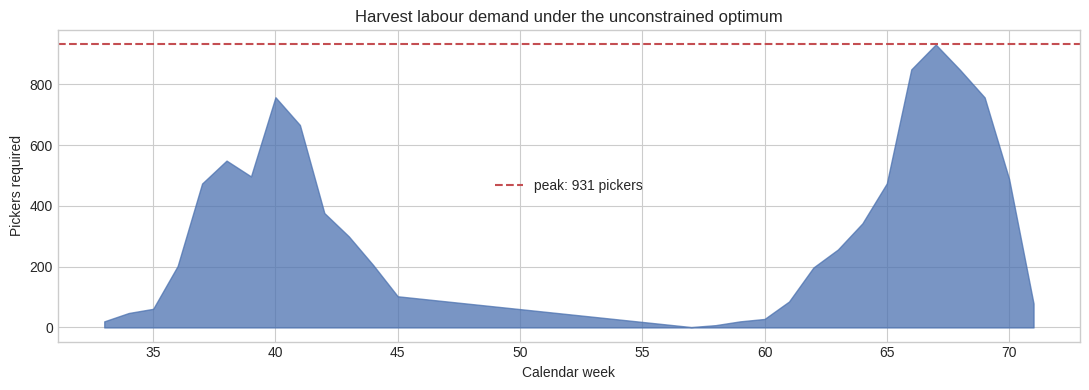

weeks with any harvest: 28
peak 931 pickers in week 67; median across active weeks 278


In [6]:
labour = weekly_labour_profile(base, options)

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(labour.index, labour.values, color="#4C72B0", alpha=0.75)
ax.axhline(base.peak_pickers, ls="--", color="#C44E52", lw=1.5,
           label=f"peak: {base.peak_pickers:,.0f} pickers")
ax.set_xlabel("Calendar week")
ax.set_ylabel("Pickers required")
ax.set_title("Harvest labour demand under the unconstrained optimum")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES}/labour_profile_base.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"weeks with any harvest: {(labour > 0).sum()}")
print(f"peak {labour.max():,.0f} pickers in week {labour.idxmax()}; "
      f"median across active weeks {labour[labour > 0].median():,.0f}")

Because every greenhouse plants the same scenario in the same week, every
greenhouse also harvests in the same week. The labour profile is a single
spike: a crew of 931 for a handful of weeks, and nobody for the rest of the
season. No farm staffs that way, and the cost of trying is nowhere in the
objective.

This is the gap between an optimum and a plan. Notebook 2 prices it.